# Ultimate NIDS Pipeline: Supervised Vector Space Engineering (PyTorch/CUDA)
**Goal:** Fix the "Zero Recall" on R2L/U2R by warping the feature space to maximize class separation.

**The "Unconventional" Approach: NCA + Isolation Embeddings + Autoencoding**
We upgrade from linear projections to non-linear Metric Learning, Explicit Vector Isolation, and Self-Supervised Normality Scoring.

**New Architecture:**
1.  **Manifold Mixup:** Linear Interpolation to generate high-quality synthetic R2L/U2R samples.
2.  **Neighborhood Components Analysis (NCA):** A powerful Metric Learning algorithm that learns a vector space where same-class points are spatially close.
3.  **Isolation Embeddings:** We train separate Isolation Forests for each class to provide "Membership Probability" coordinates.
4.  **Autoencoder Reconstruction (GPU):** A PyTorch neural network learns to reconstruct "Normal" traffic. The reconstruction error serves as a powerful "Weirdness Score".
5.  **Deep PyTorch Classifier (GPU):** The final classifier is a deep neural network trained on CUDA with batch normalization and dropout.

## 1. Data Loading

🚀 PIPELINE: DINOv2 + PROXY ANCHOR + AUX LEARNING on: cuda
Loading Data/network_connections.csv...

--- PHASE A: PREPROCESSING & META-GENERATION ---
   Generating NCA Targets...
   Generating IsoForest Targets...

--- PHASE 1: PRETRAINING (DINO + iBOT) ---
DINO Epoch 1 | Loss: 6.4139
DINO Epoch 2 | Loss: 5.6843
DINO Epoch 3 | Loss: 5.4196
DINO Epoch 4 | Loss: 5.2206
DINO Epoch 5 | Loss: 5.1213
DINO Epoch 6 | Loss: 4.9957
DINO Epoch 7 | Loss: 4.9263
DINO Epoch 8 | Loss: 4.8355
DINO Epoch 9 | Loss: 4.8059
DINO Epoch 10 | Loss: 4.7670

--- PHASE 2: PROXY ANCHOR + AUXILIARY FINE-TUNING ---
ProxyFT Epoch 1 | Loss: 9.3775
ProxyFT Epoch 2 | Loss: 3.9442
ProxyFT Epoch 3 | Loss: 2.8804
ProxyFT Epoch 4 | Loss: 2.5623
ProxyFT Epoch 5 | Loss: 2.3741
ProxyFT Epoch 6 | Loss: 2.1537
ProxyFT Epoch 7 | Loss: 1.9879
ProxyFT Epoch 8 | Loss: 1.7404
ProxyFT Epoch 9 | Loss: 1.7886
ProxyFT Epoch 10 | Loss: 1.7251

--- PHASE 3: TRAINING MLP PROBE WITH FOCAL LOSS ---
Probe Epoch 1 | Focal Loss: 0.0144
Probe Epo

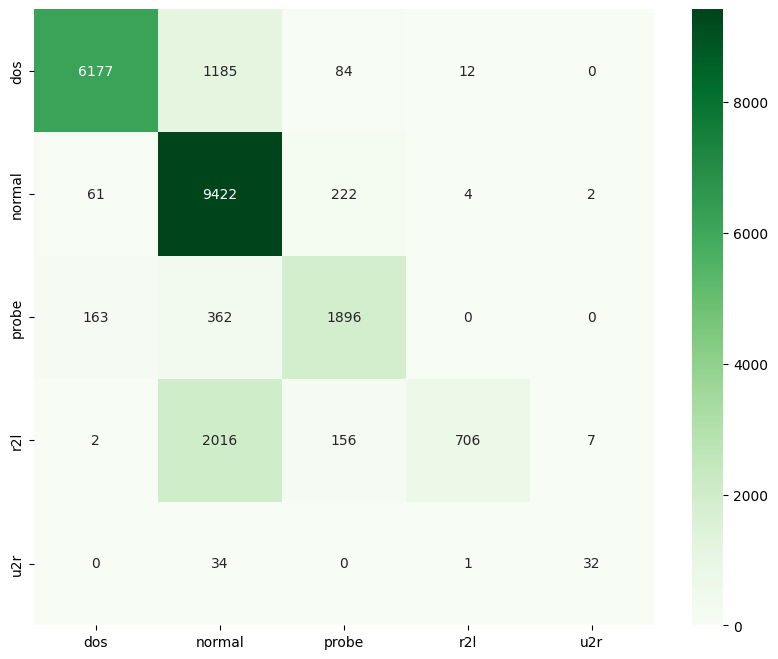

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, matthews_corrcoef, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import gc

# Config
warnings.filterwarnings("ignore")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
scaler_amp = torch.cuda.amp.GradScaler()
print(f"🚀 PIPELINE: DINOv2 + PROXY ANCHOR + AUX LEARNING on: {device}")

# ==========================================
# 1. SETUP & DATA LOADING
# ==========================================
attack_map = {
    'normal': 'normal',
    'neptune': 'dos', 'back': 'dos', 'land': 'dos', 'pod': 'dos', 'smurf': 'dos', 'teardrop': 'dos', 'mailbomb': 'dos', 'apache2': 'dos', 'processtable': 'dos', 'udpstorm': 'dos', 
    'ipsweep': 'probe', 'nmap': 'probe', 'portsweep': 'probe', 'satan': 'probe', 'mscan': 'probe', 'saint': 'probe',
    'ftp_write': 'r2l', 'guess_passwd': 'r2l', 'imap': 'r2l', 'multihop': 'r2l', 'phf': 'r2l', 'spy': 'r2l', 'warezclient': 'r2l', 'warezmaster': 'r2l', 'sendmail': 'r2l', 'named': 'r2l', 'snmpgetattack': 'r2l', 'snmpguess': 'r2l', 'xlock': 'r2l', 'xsnoop': 'r2l', 'worm': 'r2l', 'httptunnel': 'r2l',
    'buffer_overflow': 'u2r', 'loadmodule': 'u2r', 'perl': 'u2r', 'rootkit': 'u2r', 'ps': 'u2r', 'sqlattack': 'u2r', 'xterm': 'u2r'
}

def load_and_prep(path):
    print(f"Loading {path}...")
    df = pd.read_csv(path)
    df['label'] = df['label'].astype(str).str.replace('.', '', regex=False)
    df['category'] = df['label'].map(attack_map).fillna('other')
    
    if 'src_bytes' in df.columns:
        df['byte_ratio'] = (np.log1p(df['src_bytes'])) / (np.log1p(df['dst_bytes']) + 1)
        df['srv_diff'] = df['srv_count'] - df['count']
    
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df.columns: df[c] = np.log1p(df[c])
            
    X = df.drop(['label', 'category'], axis=1).select_dtypes(include=[np.number])
    y = df['category']
    return X, y

# Load Data
try:
    X, y = load_and_prep('Data/network_connections.csv')
except FileNotFoundError:
    print("⚠️ Using Dummy Data")
    X = pd.DataFrame(np.random.rand(2000, 20), columns=[f'col_{i}' for i in range(20)])
    y = pd.Series(np.random.choice(['normal', 'dos', 'u2r'], 2000))

le = LabelEncoder()
y_vec = le.fit_transform(y)
num_classes = len(le.classes_)

# Split
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X, y_vec, test_size=0.2, stratify=y_vec, random_state=42)
train_cols = X.columns.tolist()

del X, y
gc.collect()

# ==========================================
# 2. FEATURE ENGINEERING (AUXILIARY TARGETS)
# ==========================================
print("\n--- PHASE A: PREPROCESSING & META-GENERATION ---")
scaler = StandardScaler()
X_train_final = scaler.fit_transform(X_train_raw).astype(np.float32)

# 1. NCA Targets
print("   Generating NCA Targets...")
nca = NeighborhoodComponentsAnalysis(n_components=10, random_state=42)
idx_sample = np.random.choice(len(X_train_final), size=min(2000, len(X_train_final)), replace=False)
nca.fit(X_train_final[idx_sample], y_train[idx_sample])
X_train_nca = nca.transform(X_train_final).astype(np.float32)

# 2. Isolation Forest Targets
print("   Generating IsoForest Targets...")
iso_feats = []
for cls_idx in np.unique(y_train):
    X_cls = X_train_final[y_train == cls_idx]
    if len(X_cls) < 20: 
        iso = IsolationForest(n_estimators=50, contamination='auto').fit(X_train_final)
    else:
        iso = IsolationForest(n_estimators=50, contamination='auto').fit(X_cls)
    iso_feats.append(iso.decision_function(X_train_final).reshape(-1, 1))
X_train_iso = np.hstack(iso_feats).astype(np.float32)

# Combine Raw + Meta Targets
# Dataset: [Raw_Input, Label, Meta_Target]
Meta_Targets = np.hstack([X_train_nca, X_train_iso])
meta_dim = Meta_Targets.shape[1]

X_train_tensor = torch.tensor(X_train_final, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
meta_train_tensor = torch.tensor(Meta_Targets, dtype=torch.float32)

del X_train_raw
gc.collect()

# ==========================================
# 3. COMPONENTS & LOSSES
# ==========================================

class ProxyAnchorLoss(nn.Module):
    def __init__(self, num_classes, embed_dim, margin=0.1, alpha=32):
        super().__init__()
        self.num_classes = num_classes
        self.margin = margin
        self.alpha = alpha
        # Proxies sind lernbare Parameter ("Leuchttürme")
        self.proxies = nn.Parameter(torch.randn(num_classes, embed_dim))
        nn.init.kaiming_normal_(self.proxies, mode='fan_out')

    def forward(self, embeddings, labels):
        P = F.normalize(self.proxies, p=2, dim=1)
        X = F.normalize(embeddings, p=2, dim=1)
        
        cos_sim = torch.matmul(X, P.t()) # [Batch, Classes]
        
        one_hot = torch.eye(self.num_classes, device=embeddings.device)[labels]
        
        # Pull Positive
        pos_term = torch.exp(-self.alpha * (cos_sim - self.margin))
        pos_term = torch.where(one_hot == 1, pos_term, torch.zeros_like(pos_term))
        loss_pos = torch.log(1 + pos_term.sum(dim=0)).mean()
        
        # Push Negative
        neg_term = torch.exp(self.alpha * (cos_sim + self.margin))
        neg_term = torch.where(one_hot == 0, neg_term, torch.zeros_like(neg_term))
        loss_neg = torch.log(1 + neg_term.sum(dim=0)).mean()
        
        return loss_pos + loss_neg

class KoLeoLoss(nn.Module):
    def __init__(self): super().__init__()
    def forward(self, student_output, eps=1e-8):
        x = F.normalize(student_output, p=2, dim=1)
        dots = torch.mm(x, x.t())
        dots.view(-1)[::x.shape[0]+1] = -float('inf') 
        _, I = torch.max(dots, dim=1)
        nearest_neighbor = x[I]
        dot_product = (x * nearest_neighbor).sum(dim=1)
        return -torch.log(torch.sqrt(2 * (1 - dot_product + eps)) + eps).mean()

class SinkhornKnopp(nn.Module):
    def __init__(self, num_prototypes, epsilon=0.05, iterations=3, use_queue=True, queue_size=2048):
        super().__init__()
        self.epsilon = epsilon; self.iterations = iterations; self.use_queue = use_queue
        if use_queue:
            self.register_buffer("queue", torch.randn(queue_size, num_prototypes))
            self.queue = F.normalize(self.queue, dim=1)
            self.register_buffer("queue_ptr", torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def update_queue(self, teacher_output):
        if not self.use_queue: return
        batch_size = teacher_output.shape[0]
        ptr = int(self.queue_ptr)
        if ptr + batch_size <= self.queue.shape[0]:
            self.queue[ptr:ptr+batch_size] = teacher_output
        else:
            rem = self.queue.shape[0] - ptr
            self.queue[ptr:] = teacher_output[:rem]
        self.queue_ptr[0] = (ptr + batch_size) % self.queue.shape[0]

    @torch.no_grad()
    def forward(self, teacher_output):
        teacher_output = teacher_output.float()
        if self.use_queue:
            full_support = torch.cat([teacher_output, self.queue.clone().detach().float()], dim=0)
        else: full_support = teacher_output
        Q = torch.exp(full_support / self.epsilon).t()
        B = Q.shape[1]; K = Q.shape[0]; sum_Q = torch.sum(Q); Q /= sum_Q
        for _ in range(self.iterations):
            Q /= torch.sum(Q, dim=1, keepdim=True); Q /= K
            Q /= torch.sum(Q, dim=0, keepdim=True); Q /= B
        Q *= B
        return Q.t()[:teacher_output.shape[0]]

# ==========================================
# 4. ARCHITECTURE (With Aux Head)
# ==========================================

class TabularPatchEmbed(nn.Module):
    def __init__(self, num_features, embed_dim):
        super().__init__()
        self.proj = nn.Parameter(torch.randn(num_features, embed_dim) / np.sqrt(embed_dim))
        self.bias = nn.Parameter(torch.zeros(num_features, embed_dim))
    def forward(self, x):
        return x.unsqueeze(-1) * self.proj.unsqueeze(0) + self.bias.unsqueeze(0)

class TabularViT(nn.Module):
    def __init__(self, input_dim, embed_dim=64, depth=4, num_registers=4, aux_dim=0):
        super().__init__()
        self.patch_embed = TabularPatchEmbed(input_dim, embed_dim)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))
        self.registers = nn.Parameter(torch.zeros(1, num_registers, embed_dim))
        
        enc = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=4, dim_feedforward=256, 
                                         batch_first=True, norm_first=True, activation='gelu', dropout=0.1)
        self.transformer = nn.TransformerEncoder(enc, num_layers=depth)
        
        # Auxiliary Head (for Phase 2 Meta-Prediction)
        if aux_dim > 0:
            self.aux_head = nn.Sequential(
                nn.Linear(embed_dim, 64), nn.ReLU(), nn.Linear(64, aux_dim)
            )
        else:
            self.aux_head = None

    def forward(self, x):
        x_emb = self.patch_embed(x) 
        b = x.shape[0]
        cls_tokens = self.cls_token.expand(b, -1, -1)
        regs = self.registers.expand(b, -1, -1)
        x_seq = torch.cat((cls_tokens, regs, x_emb), dim=1)
        x_out = self.transformer(x_seq)
        
        cls_out = x_out[:, 0, :]
        
        aux_out = None
        if self.aux_head is not None:
            aux_out = self.aux_head(cls_out)
            
        return cls_out, x_out[:, 1+self.registers.shape[1]:, :], aux_out

class DINOHead(nn.Module):
    def __init__(self, in_dim, out_dim, hidden_dim=256, bottleneck_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.GELU(),
            nn.Linear(hidden_dim, bottleneck_dim),
        )
        self.last_layer = nn.utils.weight_norm(nn.Linear(bottleneck_dim, out_dim, bias=False))
        self.last_layer.weight_g.data.fill_(1)
    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)
        return self.last_layer(x)

class MIMHead(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.decoder = nn.Sequential(nn.Linear(embed_dim, embed_dim), nn.GELU(), nn.Linear(embed_dim, 1))
    def forward(self, x_seq): return self.decoder(x_seq).squeeze(-1)

# ==========================================
# 5. DATA SAMPLING
# ==========================================
class TabularMIMCollator:
    def __init__(self, mask_ratio=0.4, noise=0.05):
        self.mask_ratio = mask_ratio; self.noise = noise
    def __call__(self, batch):
        x = torch.stack([item[0] for item in batch])
        y = torch.stack([item[1] for item in batch])
        meta = torch.stack([item[2] for item in batch]) # Pass meta
        
        x_teacher = x.clone() + torch.randn_like(x) * self.noise
        mask = torch.rand_like(x) < self.mask_ratio
        x_student = x.clone()
        x_student[mask] = 0 
        x_student = x_student + torch.randn_like(x) * self.noise
        return x_teacher, x_student, mask, y, meta

class_counts = np.bincount(y_train)
sample_weights = (1. / (np.log1p(class_counts) + 1e-6))[y_train]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(y_train), replacement=True)

# ==========================================
# 6. TRAINING LOOP
# ==========================================
BATCH_SIZE = 64
GRAD_ACCUM = 4
EMBED_DIM = 64
NUM_PROTOTYPES = 1024

# Student hat jetzt aux_dim für Phase 2
student_enc = TabularViT(X_train_final.shape[1], EMBED_DIM, aux_dim=meta_dim).to(device)
student_dino = DINOHead(EMBED_DIM, NUM_PROTOTYPES).to(device)
student_mim = MIMHead(EMBED_DIM).to(device)

teacher_enc = TabularViT(X_train_final.shape[1], EMBED_DIM, aux_dim=meta_dim).to(device)
teacher_dino = DINOHead(EMBED_DIM, NUM_PROTOTYPES).to(device)

teacher_enc.load_state_dict(student_enc.state_dict())
teacher_dino.load_state_dict(student_dino.state_dict())
for p in teacher_enc.parameters(): p.requires_grad = False
for p in teacher_dino.parameters(): p.requires_grad = False

sinkhorn = SinkhornKnopp(NUM_PROTOTYPES).to(device)
koleo = KoLeoLoss().to(device)
optimizer = optim.AdamW(list(student_enc.parameters()) + list(student_dino.parameters()) + list(student_mim.parameters()), lr=0.001)

collator = TabularMIMCollator(mask_ratio=0.5)
# Dataset needs 3 items: Raw, Label, Meta
train_dl = DataLoader(TensorDataset(X_train_tensor, y_train_tensor, meta_train_tensor), 
                      batch_size=BATCH_SIZE, sampler=sampler, shuffle=False, 
                      collate_fn=collator, drop_last=True)

def update_teacher(m):
    with torch.no_grad():
        for ps, pt in zip(student_enc.parameters(), teacher_enc.parameters()):
            pt.data = pt.data * m + ps.data * (1 - m)
        for ps, pt in zip(student_dino.parameters(), teacher_dino.parameters()):
            pt.data = pt.data * m + ps.data * (1 - m)

print("\n--- PHASE 1: PRETRAINING (DINO + iBOT) ---")
for epoch in range(10): # Reduced epochs for demo
    student_enc.train(); student_dino.train(); student_mim.train()
    loss_total = 0
    m = 0.996 + (1.0 - 0.996) * (epoch / 10)
    
    optimizer.zero_grad()
    for i, (x_t, x_s, mask, _, _) in enumerate(train_dl): # Ignore label/meta here
        x_t, x_s, mask = x_t.to(device), x_s.to(device), mask.to(device)
        
        with torch.cuda.amp.autocast():
            s_cls, s_seq, _ = student_enc(x_s) # Ignore Aux
            s_dino_out = student_dino(s_cls)
            s_rec = student_mim(s_seq)
            
            with torch.no_grad():
                t_cls, _, _ = teacher_enc(x_t)
                t_dino_out = teacher_dino(t_cls)
            
            t_targets = sinkhorn(t_dino_out)
            l_dino = -torch.sum(t_targets * F.log_softmax(s_dino_out / 0.1, dim=-1), dim=-1).mean()
            l_mim = F.mse_loss(s_rec[mask], x_t[mask])
            l_koleo = koleo(s_cls)
            
            loss = (l_dino + 0.5 * l_mim + 0.1 * l_koleo) / GRAD_ACCUM
        
        scaler_amp.scale(loss).backward()
        
        if (i+1) % GRAD_ACCUM == 0:
            scaler_amp.step(optimizer)
            scaler_amp.update()
            optimizer.zero_grad()
            update_teacher(m)
            sinkhorn.update_queue(t_dino_out)
            
        loss_total += loss.item() * GRAD_ACCUM
    print(f"DINO Epoch {epoch+1} | Loss: {loss_total/len(train_dl):.4f}")

# ==========================================
# PHASE 2: PROXY ANCHOR + AUX FINE-TUNING
# ==========================================
print("\n--- PHASE 2: PROXY ANCHOR + AUXILIARY FINE-TUNING ---")

# 1. Initialize Proxy Loss
proxy_loss_fn = ProxyAnchorLoss(num_classes, EMBED_DIM).to(device)
aux_loss_fn = nn.MSELoss()

# 2. Setup Optimizer (Includes Proxies!)
# Wir trainieren den Encoder und die Proxies
opt_ft = optim.AdamW(list(student_enc.parameters()) + list(proxy_loss_fn.parameters()), lr=0.0001)

train_dl_ft = DataLoader(TensorDataset(X_train_tensor, y_train_tensor, meta_train_tensor), 
                         batch_size=128, sampler=sampler, shuffle=False)

for epoch in range(10):
    student_enc.train()
    loss_acc = 0
    for x, y, meta in train_dl_ft:
        x, y, meta = x.to(device), y.to(device), meta.to(device)
        
        opt_ft.zero_grad()
        
        # Forward: Get Embeddings AND Aux Prediction
        embeddings, _, aux_pred = student_enc(x)
        
        # 1. Proxy Anchor Loss (Structure the Space)
        l_proxy = proxy_loss_fn(embeddings, y)
        
        # 2. Auxiliary Loss (Learn the Physics/Meta)
        l_aux = aux_loss_fn(aux_pred, meta)
        
        # Combined Loss
        loss = l_proxy + (0.5 * l_aux)
        
        loss.backward()
        opt_ft.step()
        
        loss_acc += loss.item()
    print(f"ProxyFT Epoch {epoch+1} | Loss: {loss_acc/len(train_dl_ft):.4f}")

# ==========================================
# PHASE 3: TRAINING MLP PROBE (FOCAL LOSS)
# ==========================================
print("\n--- PHASE 3: TRAINING MLP PROBE WITH FOCAL LOSS ---")

# 1. Focal Loss Definition (Aggressiv gegen Imbalance)
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2, reduction='mean'):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean() if self.reduction == 'mean' else focal_loss.sum()

# 2. MLP Probe Architecture (Statt simplem Linear Layer)
class MLPProbe(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, num_classes)
        )
    def forward(self, x): return self.net(x)

# 3. Freeze Backbone (Wir nutzen die gelernten "Physics" Features)
for p in student_enc.parameters(): p.requires_grad = False
student_enc.eval()

# 4. Setup Probe Training
probe = MLPProbe(EMBED_DIM, num_classes).to(device)
opt_probe = optim.AdamW(probe.parameters(), lr=0.001, weight_decay=1e-4)
crit_focal = FocalLoss(gamma=2.0) # Gamma=2 fokussiert stark auf harte Fehler

# DataLoader hat nur (X, y) -> FIX: Unpacking Error
train_dl_lin = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), 
                          batch_size=256, sampler=sampler, shuffle=False)

for epoch in range(15):
    probe.train()
    loss_acc = 0
    
    # FIX: Hier stand vorher "for x, y, _" -> Jetzt nur "for x, y"
    for x, y in train_dl_lin:
        x, y = x.to(device), y.to(device)
        
        with torch.no_grad(): 
            # Features aus dem gefrorenen Backbone holen
            # Wir nutzen Output 1 (CLS Token)
            feat, _, _ = student_enc(x) 
            # WICHTIG: Normalisieren, da Proxy-Loss den Raum sphärisch geformt hat!
            feat = F.normalize(feat, p=2, dim=1) 
        
        opt_probe.zero_grad()
        logits = probe(feat)
        loss = crit_focal(logits, y)
        loss.backward()
        opt_probe.step()
        
        loss_acc += loss.item()
        
    print(f"Probe Epoch {epoch+1} | Focal Loss: {loss_acc/len(train_dl_lin):.4f}")

# ==========================================
# 6. EVALUATION (HARD TEST)
# ==========================================
print("\n--- PHASE E: FINAL EVALUATION (Raw -> Backbone -> MLP Probe) ---")
NSL_URL = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTest%2B.txt"
NSL_COLS = ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level']

try:
    df_nsl = pd.read_csv(NSL_URL, header=None, names=NSL_COLS)
    if 'difficulty_level' in df_nsl.columns: df_nsl.drop('difficulty_level', axis=1, inplace=True)
    df_nsl['label'] = df_nsl['label'].astype(str).str.replace('.', '', regex=False)
    df_nsl['category'] = df_nsl['label'].map(attack_map).fillna('other')
    
    # Feature Engineering (Test)
    if 'src_bytes' in df_nsl.columns:
        df_nsl['byte_ratio'] = (np.log1p(df_nsl['src_bytes'])) / (np.log1p(df_nsl['dst_bytes']) + 1)
        df_nsl['srv_diff'] = df_nsl['srv_count'] - df_nsl['count']
    for c in ['src_bytes', 'dst_bytes', 'duration', 'wrong_fragment', 'urgent']:
        if c in df_nsl.columns: df_nsl[c] = np.log1p(df_nsl[c])
            
    df_nsl_aligned = pd.DataFrame(0, index=np.arange(len(df_nsl)), columns=train_cols)
    for c in train_cols:
        if c in df_nsl.columns: df_nsl_aligned[c] = df_nsl[c]

    y_nsl_vec = df_nsl['category'].apply(lambda x: le.transform([x])[0] if x in le.classes_ else -1).values
    X_nsl_sc = scaler.transform(df_nsl_aligned).astype(np.float32)
    X_test_tensor_cpu = torch.tensor(X_nsl_sc)

    # Eval Loop (Updated for Probe)
    probe.eval()
    
    def predict_batched_probe(backbone, mlp, x_cpu):
        x_gpu = x_cpu.to(device)
        with torch.no_grad():
            # 1. Backbone Features
            s_cls, _, _ = backbone(x_gpu) # Ignore Aux
            s_cls = F.normalize(s_cls, p=2, dim=1) 
            # 2. MLP Probe Prediction
            logits = mlp(s_cls)
            probs = torch.softmax(logits, dim=1)
        return probs.cpu().numpy()

    all_probs = []
    loader = DataLoader(TensorDataset(X_test_tensor_cpu), batch_size=2048)
    for bx in loader:
        p = predict_batched_probe(student_enc, probe, bx[0]) 
        all_probs.append(p)
    probs_np = np.concatenate(all_probs)

    final_preds = np.argmax(probs_np, axis=1)
    mask = y_nsl_vec != -1

    acc = accuracy_score(y_nsl_vec[mask], final_preds[mask])
    mcc = matthews_corrcoef(y_nsl_vec[mask], final_preds[mask])
    
    

    print("\n" + "="*40)
    print(f" 👑 FINAL RESULTS (Backbone + Focal MLP): {acc:.2%} (MCC: {mcc:.4f}) 👑")
    print("="*40)
    print(classification_report(y_nsl_vec[mask], final_preds[mask], target_names=le.classes_))
    
    labels = sorted(list(set(y_nsl_vec[mask]) | set(final_preds[mask])))
    label_names = [le.classes_[i] for i in labels]
    plt.figure(figsize=(10,8))
    sns.heatmap(confusion_matrix(y_nsl_vec[mask], final_preds[mask], labels=labels), 
                annot=True, fmt='d', cmap='Greens', xticklabels=label_names, yticklabels=label_names)
    plt.show()

except Exception as e:
    print(f"Evaluation Error: {e}")
    import traceback
    traceback.print_exc()